# EchoPath — YOLO + Depth Anything V2 Pipeline (HPC / Local GPU)
**Fine-tuned YOLO + DA V2 Small → Proximity zones → Audio alerts**

Assumes your environment is already set up via `uv` with all dependencies installed (torch, ultralytics, transformers, opencv-python, matplotlib, imageio-ffmpeg).

### Run order
1. Cell 1 — Verify GPU
2. Cell 2 — Set paths
3. Cell 3 — Load models
4. Cell 4 — Core pipeline functions
5. Cell 5 — Depth calibration (tune thresholds)
6. **Cell 6 — Rotation diagnostic** (run this to pick the right rotation mode)
7. Cell 7 — Process video(s)
8. Cell 8 — Summary


## Cell 1 — Verify GPU

In [1]:
import torch


print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected — pipeline will be very slow on CPU')


PyTorch version : 2.4.1+cu118
CUDA available  : True
GPU             : NVIDIA RTX 4500 Ada Generation
VRAM            : 25.8 GB


## Cell 2 — Set paths (edit these before running anything else)

In [2]:
import os

# ── EDIT THESE BASE PATHS ─────────────────────────────────────────────────────
YOLO_WEIGHTS = r"E:\EchoPath\runs\detect\runs\echopath\v3\weights\best.pt"
VIDEO_DIR    = r"E:\EchoPath\Video_Data"   # drop any video here, it gets picked up automatically
OUTPUT_DIR   = r"E:\EchoPath\Depth Analysis V2\output"
# ─────────────────────────────────────────────────────────────────────────────

SUPPORTED_EXTS = {'.mp4', '.avi', '.mov', '.mkv', '.MOV', '.MP4'}

os.makedirs(OUTPUT_DIR, exist_ok=True)
assert os.path.exists(YOLO_WEIGHTS), f'YOLO weights not found: {YOLO_WEIGHTS}'
assert os.path.exists(VIDEO_DIR),    f'Video folder not found: {VIDEO_DIR}'

# Auto-discover all videos in the folder
VIDEO_JOBS = [
    (
        os.path.join(VIDEO_DIR, f),
        os.path.join(OUTPUT_DIR, f"echopath_{f}")
    )
    for f in sorted(os.listdir(VIDEO_DIR))
    if os.path.splitext(f)[1] in SUPPORTED_EXTS
]

assert len(VIDEO_JOBS) > 0, f'No videos found in {VIDEO_DIR}. Supported formats: {SUPPORTED_EXTS}'

print(f'Weights : {YOLO_WEIGHTS}')
print(f'Found {len(VIDEO_JOBS)} video(s) in {VIDEO_DIR}:')
for inp, out in VIDEO_JOBS:
    print(f'  {os.path.basename(inp)}  →  {os.path.basename(out)}')

# TIP: to test on just ONE video first, uncomment the next line:
# VIDEO_JOBS = VIDEO_JOBS[:1]


Weights : E:\EchoPath\runs\detect\runs\echopath\v3\weights\best.pt
Found 13 video(s) in E:\EchoPath\Video_Data:
  Classroom.MP4  →  echopath_Classroom.MP4
  Enterance.MP4  →  echopath_Enterance.MP4
  FDW.mp4  →  echopath_FDW.mp4
  Manthan.mp4  →  echopath_Manthan.mp4
  Persons.mp4  →  echopath_Persons.mp4
  Stairs.MP4  →  echopath_Stairs.MP4
  Water.mp4  →  echopath_Water.mp4
  acad_entry.mp4  →  echopath_acad_entry.mp4
  first_floor.mp4  →  echopath_first_floor.mp4
  lab.mp4  →  echopath_lab.mp4
  sign.mp4  →  echopath_sign.mp4
  trash_bin.mp4  →  echopath_trash_bin.mp4
  water1.mp4  →  echopath_water1.mp4


## Cell 3 — Load models

In [3]:
from ultralytics import YOLO
from transformers import pipeline as hf_pipeline

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Fine-tuned YOLO
yolo_model = YOLO(YOLO_WEIGHTS)
print('YOLO loaded')

# Depth Anything V2 Small — relative depth
# To switch to metric depth (actual meters), change model to:
#   'depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf'
depth_pipe = hf_pipeline(
    task='depth-estimation',
    model='depth-anything/Depth-Anything-V2-Small-hf',
    device=0 if device == 'cuda' else -1
)
print('Depth Anything V2 Small loaded')


Using device: cuda
YOLO loaded


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

Depth Anything V2 Small loaded


## Cell 4 — Core pipeline functions

In [4]:
import numpy as np
import cv2
from PIL import Image
import imageio_ffmpeg
import subprocess
FFMPEG_EXE = imageio_ffmpeg.get_ffmpeg_exe()

# ── TUNE THESE after running Cell 5 (calibration) on your corridor footage ───
CLOSE_THRESH  = 0.70   # normalized depth > 0.70 → 'close'
MEDIUM_THRESH = 0.40   # normalized depth > 0.40 → 'medium', else 'far'
CONF_THRESH   = 0.40   # YOLO confidence threshold
# ─────────────────────────────────────────────────────────────────────────────

def get_video_rotation(video_path):
    """Read rotation from displaymatrix metadata (modern iOS/Android videos)."""
    import subprocess, re
    result = subprocess.run(
        [FFMPEG_EXE, '-i', video_path],
        capture_output=True, text=True
    )
    # Modern format: "displaymatrix: rotation of -90.00 degrees"
    match = re.search(r'displaymatrix:\s*rotation of\s*([+-]?\d+(?:\.\d+)?)\s*degrees',
                      result.stderr)
    if match:
        return int(float(match.group(1)))

    # Fallback: old format "rotate: 90"
    match = re.search(r'rotate\s*:\s*([+-]?\d+)', result.stderr)
    if match:
        return int(match.group(1))

    return 0


def fix_rotation(frame, rotation):
    """Rotate frame to correct orientation based on metadata."""
    if rotation == 90:
        return cv2.rotate(frame, cv2.ROTATE_90_CLOCKWISE)
    elif rotation == 180 or rotation == -180:
        return cv2.rotate(frame, cv2.ROTATE_180)
    elif rotation == 270 or rotation == -90:
        return cv2.rotate(frame, cv2.ROTATE_90_COUNTERCLOCKWISE)
    return frame


def get_depth_and_zone(depth_map, bbox, frame_width):
    """Extract avg depth within a bounding box then map to proximity zone + direction."""
    x1, y1, x2, y2 = map(int, bbox)
    region = depth_map[y1:y2, x1:x2]
    if region.size == 0:
        return 0.0, 'far', 'ahead'

    avg_depth = float(np.mean(region))

    if avg_depth > CLOSE_THRESH:
        proximity = 'close'
    elif avg_depth > MEDIUM_THRESH:
        proximity = 'medium'
    else:
        proximity = 'far'

    cx = (x1 + x2) / 2
    third = frame_width / 3
    if cx < third:
        direction = 'left'
    elif cx < 2 * third:
        direction = 'ahead'
    else:
        direction = 'right'

    return avg_depth, proximity, direction


def generate_alerts(detections):
    """Only alert for close/medium objects; close-proximity alerts come first."""
    alerts = [d for d in detections if d['proximity'] in ('close', 'medium')]
    alerts.sort(key=lambda d: 0 if d['proximity'] == 'close' else 1)
    return alerts


def process_frame(frame):
    """Run full EchoPath pipeline on one frame."""
    h, w = frame.shape[:2]

    # YOLO detection
    results = yolo_model.predict(frame, conf=CONF_THRESH, verbose=False)[0]

    # Depth estimation
    pil_img   = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    raw_depth = np.array(depth_pipe(pil_img)['depth'], dtype=np.float32)

    # Normalize to 0-1  (higher value = closer to camera)
    # If close objects appear as 'far' in output, flip with:  depth_map = 1.0 - depth_map
    d_min, d_max = raw_depth.min(), raw_depth.max()
    depth_map = (raw_depth - d_min) / (d_max - d_min + 1e-6)
    depth_map = cv2.resize(depth_map, (w, h))

    # Fusion — combine YOLO boxes with depth map
    detections = []
    for box in results.boxes:
        bbox      = box.xyxy[0].cpu().numpy()
        label     = yolo_model.names[int(box.cls[0])]
        conf      = float(box.conf[0])
        avg_depth, proximity, direction = get_depth_and_zone(depth_map, bbox, w)
        detections.append(dict(label=label, bbox=bbox, conf=conf,
                               depth=avg_depth, proximity=proximity,
                               direction=direction))

    alerts = generate_alerts(detections)

    # Annotate frame
    annotated = frame.copy()
    COLOR = {'close': (0, 0, 255), 'medium': (0, 165, 255), 'far': (0, 200, 0)}
    for d in detections:
        x1, y1, x2, y2 = map(int, d['bbox'])
        c   = COLOR[d['proximity']]
        txt = f"{d['label']} | {d['proximity']} | {d['direction']} | d={d['depth']:.2f}"
        cv2.rectangle(annotated, (x1, y1), (x2, y2), c, 2)
        cv2.putText(annotated, txt, (x1, y1 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, c, 2)

    return annotated, alerts, depth_map


print('Pipeline functions ready!')


Pipeline functions ready!


## Cell 5 — Depth calibration helper
**Run this before Cell 7.** It samples one frame and prints depth statistics so you can set the right thresholds in Cell 4.


e:\EchoPath\.venv\Lib\site-packages\transformers\integrations\sdpa_attention.py:92: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


Calibration frame from: Classroom.MP4

Depth map stats (normalized 0-1):
  min  = 0.000
  max  = 1.000
  mean = 0.414
  25th percentile = 0.129
  50th percentile = 0.404
  75th percentile = 0.643

Recommended threshold starting points:
  CLOSE_THRESH  ≈ 0.64  (75th percentile)
  MEDIUM_THRESH ≈ 0.40  (50th percentile)

Update CLOSE_THRESH and MEDIUM_THRESH in Cell 4, then run Cell 7.


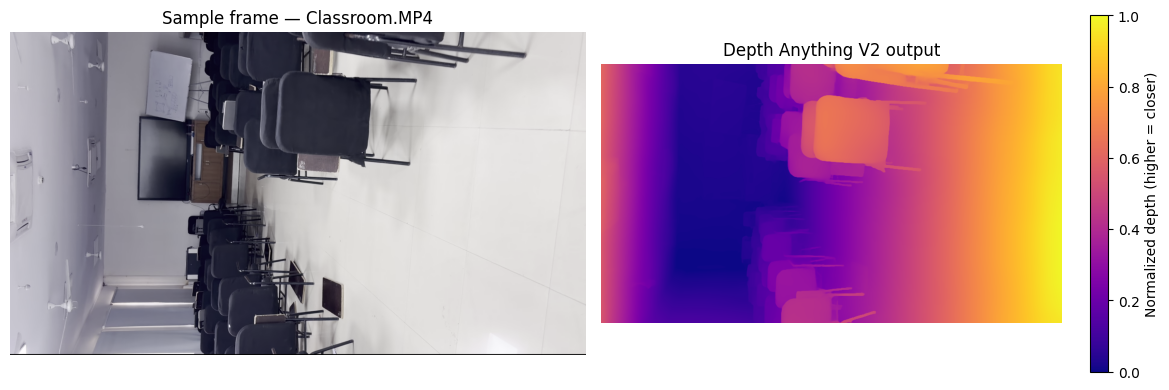

Depth map saved to: E:\EchoPath\Depth Analysis V2\output\depth_calibration.png


In [5]:
import matplotlib.pyplot as plt

SAMPLE_FRAME = 30
SAMPLE_VIDEO = VIDEO_JOBS[0][0]

cap = cv2.VideoCapture(SAMPLE_VIDEO)
for _ in range(SAMPLE_FRAME):
    ret, frame = cap.read()
    if not ret:
        break
cap.release()

# NOTE: this preview does NOT apply manual rotation — on modern OpenCV the
# frame comes out correctly oriented. If the preview looks rotated, see Cell 6.

pil_img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
raw     = np.array(depth_pipe(pil_img)['depth'], dtype=np.float32)
norm    = (raw - raw.min()) / (raw.max() - raw.min() + 1e-6)

print(f'Calibration frame from: {os.path.basename(SAMPLE_VIDEO)}')
print()
print('Depth map stats (normalized 0-1):')
print(f'  min  = {norm.min():.3f}')
print(f'  max  = {norm.max():.3f}')
print(f'  mean = {norm.mean():.3f}')
print(f'  25th percentile = {np.percentile(norm, 25):.3f}')
print(f'  50th percentile = {np.percentile(norm, 50):.3f}')
print(f'  75th percentile = {np.percentile(norm, 75):.3f}')
print()
print('Recommended threshold starting points:')
print(f'  CLOSE_THRESH  ≈ {np.percentile(norm, 75):.2f}  (75th percentile)')
print(f'  MEDIUM_THRESH ≈ {np.percentile(norm, 50):.2f}  (50th percentile)')
print()
print('Update CLOSE_THRESH and MEDIUM_THRESH in Cell 4, then run Cell 7.')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title(f'Sample frame — {os.path.basename(SAMPLE_VIDEO)}')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(norm, cmap='plasma')
plt.colorbar(label='Normalized depth (higher = closer)')
plt.title('Depth Anything V2 output')
plt.axis('off')
plt.tight_layout()

calib_path = os.path.join(OUTPUT_DIR, 'depth_calibration.png')
plt.savefig(calib_path, dpi=120)
plt.show()
print(f'Depth map saved to: {calib_path}')


## Cell 6 — Rotation diagnostic (run this once per dataset)

**What this does:** shows you what OpenCV delivers when reading a frame. Modern OpenCV (≥ 4.5) auto-rotates using video metadata; older versions don't. This cell tells you which case you're in.

**How to read the output:**
- Frame looks **right-side up** → leave `USE_OPENCV_AUTO_ROTATE = True` in Cell 7 ✓
- Frame looks **upside down or sideways** → set `USE_OPENCV_AUTO_ROTATE = False` in Cell 7


OpenCV orientation metadata : 90.0°
OpenCV auto-rotate enabled  : False
ffmpeg-reported rotation    : -90°
Frame shape as delivered    : (1080, 1920, 3)  (H, W, C)


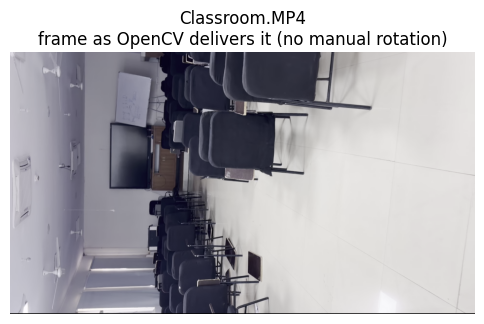


────────────────────────────────────────────────────────────
DECISION:
  If the image above is CORRECTLY oriented → Cell 7: USE_OPENCV_AUTO_ROTATE = True
  If the image above is ROTATED/UPSIDE-DOWN → Cell 7: USE_OPENCV_AUTO_ROTATE = False
────────────────────────────────────────────────────────────


In [6]:
test_video = VIDEO_JOBS[0][0]
cap = cv2.VideoCapture(test_video)

try:
    meta_rot = cap.get(cv2.CAP_PROP_ORIENTATION_META)
    auto = cap.get(cv2.CAP_PROP_ORIENTATION_AUTO)
    print(f'OpenCV orientation metadata : {meta_rot}°')
    print(f'OpenCV auto-rotate enabled  : {bool(auto)}')
except Exception as e:
    print(f'Orientation props unavailable: {e}')

ffmpeg_rot = get_video_rotation(test_video)
print(f'ffmpeg-reported rotation    : {ffmpeg_rot}°')

ret, frame = cap.read()
print(f'Frame shape as delivered    : {frame.shape}  (H, W, C)')
cap.release()

plt.figure(figsize=(6, 10))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title(f'{os.path.basename(test_video)}\nframe as OpenCV delivers it (no manual rotation)')
plt.axis('off')
plt.show()

print()
print('─' * 60)
print('DECISION:')
print('  If the image above is CORRECTLY oriented → Cell 7: USE_OPENCV_AUTO_ROTATE = True')
print('  If the image above is ROTATED/UPSIDE-DOWN → Cell 7: USE_OPENCV_AUTO_ROTATE = False')
print('─' * 60)


## Cell 7 — Process video(s)

Based on Cell 6's diagnostic, set `USE_OPENCV_AUTO_ROTATE`:
- `True` (default) if Cell 6 showed the frame correctly oriented
- `False` if the frame was rotated


In [7]:
import subprocess

PROCESS_EVERY_N = 2

# ── ROTATION MODE ─────────────────────────────────────────────────────────────
# True  = trust OpenCV's built-in rotation handling (modern OpenCV 4.5+).
# False = disable OpenCV auto-rotate and apply rotation manually from metadata.
# Set this based on what Cell 6 showed you.
USE_OPENCV_AUTO_ROTATE = True
# ─────────────────────────────────────────────────────────────────────────────

all_jobs_log = {}
FFMPEG_EXE = imageio_ffmpeg.get_ffmpeg_exe()
print(f'Using ffmpeg: {FFMPEG_EXE}')
print(f'OpenCV auto-rotate: {USE_OPENCV_AUTO_ROTATE}\n')

for job_idx, (INPUT_VIDEO, OUTPUT_VIDEO) in enumerate(VIDEO_JOBS):
    vname = os.path.basename(INPUT_VIDEO)
    print(f'{"="*60}')
    print(f'[{job_idx+1}/{len(VIDEO_JOBS)}] Processing: {vname}')
    print(f'{"="*60}')

    cap = cv2.VideoCapture(INPUT_VIDEO)

    # Explicitly set OpenCV's auto-rotation behavior
    try:
        cap.set(cv2.CAP_PROP_ORIENTATION_AUTO, 1 if USE_OPENCV_AUTO_ROTATE else 0)
    except Exception:
        pass

    # Decide what rotation WE still need to apply
    if USE_OPENCV_AUTO_ROTATE:
        manual_rotation = 0            # OpenCV already did it
    else:
        manual_rotation = get_video_rotation(INPUT_VIDEO)
    print(f'  Manual rotation to apply: {manual_rotation}°')

    # Probe one frame to get the TRUE delivered dimensions
    ret, probe = cap.read()
    if not ret:
        print('  Could not read frame, skipping.')
        cap.release()
        continue
    probe = fix_rotation(probe, manual_rotation)
    out_h, out_w = probe.shape[:2]
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)   # rewind

    fps   = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f'  Output size: {out_w}x{out_h} @ {fps:.1f} fps  |  {total} frames')

    tmp_out = OUTPUT_VIDEO.replace('.mp4', '_tmp.mp4')
    writer  = cv2.VideoWriter(tmp_out, cv2.VideoWriter_fourcc(*'mp4v'),
                              fps, (out_w, out_h))

    frame_idx      = 0
    prev_alert     = ''
    alert_log      = []
    last_annotated = None

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame = fix_rotation(frame, manual_rotation)   # no-op when auto-rotate is on

        if frame_idx % PROCESS_EVERY_N == 0:
            annotated, alerts, _ = process_frame(frame)
            last_annotated = annotated

            if alerts:
                alert_txt = f"{alerts[0]['label']} {alerts[0]['proximity']} {alerts[0]['direction']}"
                if alert_txt != prev_alert:
                    print(f'  [Frame {frame_idx:>5}] ALERT: {alert_txt}')
                    alert_log.append((frame_idx, alert_txt))
                    prev_alert = alert_txt
            else:
                prev_alert = ''

            writer.write(annotated)
        else:
            writer.write(last_annotated if last_annotated is not None else frame)

        frame_idx += 1
        if frame_idx % 200 == 0:
            print(f'  {frame_idx}/{total} frames processed...')

    cap.release()
    writer.release()

    ffmpeg_result = subprocess.run(
        [FFMPEG_EXE, '-y',
         '-noautorotate',
         '-i', tmp_out,
         '-vcodec', 'libx264',
         '-crf', '23',
         '-metadata:s:v', 'rotate=0',
         OUTPUT_VIDEO],
        capture_output=True, text=True
    )
    if ffmpeg_result.returncode == 0:
        os.remove(tmp_out)
        print(f'  Saved (h264): {OUTPUT_VIDEO}')
    else:
        os.rename(tmp_out, OUTPUT_VIDEO)
        print(f'  ffmpeg error — saved raw: {OUTPUT_VIDEO}')
        print(ffmpeg_result.stderr[-300:])

    all_jobs_log[vname] = alert_log
    print(f'  Unique alerts: {len(alert_log)}\n')

print(f'{"="*60}')
print(f'All {len(VIDEO_JOBS)} videos done. Outputs in: {OUTPUT_DIR}')


Using ffmpeg: e:\EchoPath\.venv\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe
OpenCV auto-rotate: True

[1/13] Processing: Classroom.MP4
  Manual rotation to apply: 0°
  Output size: 1080x1920 @ 30.0 fps  |  566 frames


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  [Frame   196] ALERT: chair medium left
  200/566 frames processed...
  [Frame   248] ALERT: chair medium ahead
  [Frame   258] ALERT: chair medium left
  400/566 frames processed...
  [Frame   410] ALERT: chair medium right
  [Frame   454] ALERT: chair medium right
  [Frame   478] ALERT: chair medium right
  [Frame   560] ALERT: chair medium left
  ffmpeg error — saved raw: E:\EchoPath\Depth Analysis V2\output\echopath_Classroom.MP4
endor_id       : [0][0][0][0]
Output E:\EchoPath\Depth Analysis V2\output\echopath_Classroom.MP4 same as Input #0 - exiting
FFmpeg cannot edit existing files in-place.
Error opening output file E:\EchoPath\Depth Analysis V2\output\echopath_Classroom.MP4.
Error opening output files: Invalid argument

  Unique alerts: 7

[2/13] Processing: Enterance.MP4
  Manual rotation to apply: 0°
  Output size: 1080x1920 @ 30.0 fps  |  357 frames
  200/357 frames processed...
  ffmpeg error — saved raw: E:\EchoPath\Depth Analysis V2\output\echopath_Enterance.MP4
endor_i

## Cell 8 — Video summary

In [8]:
for vname, log in all_jobs_log.items():
    inp_path = os.path.join(VIDEO_DIR, vname)
    cap_tmp  = cv2.VideoCapture(inp_path)
    fps_tmp  = cap_tmp.get(cv2.CAP_PROP_FPS)
    cap_tmp.release()
    print(f'\n── {vname} ({len(log)} unique alerts) ──')
    for frame_n, txt in log:
        ts = frame_n / fps_tmp if fps_tmp > 0 else 0
        print(f'  [{ts:6.2f}s | Frame {frame_n:>5}]  {txt}')



── Classroom.MP4 (7 unique alerts) ──
  [  6.53s | Frame   196]  chair medium left
  [  8.27s | Frame   248]  chair medium ahead
  [  8.60s | Frame   258]  chair medium left
  [ 13.67s | Frame   410]  chair medium right
  [ 15.13s | Frame   454]  chair medium right
  [ 15.93s | Frame   478]  chair medium right
  [ 18.67s | Frame   560]  chair medium left

── Enterance.MP4 (0 unique alerts) ──

── FDW.mp4 (2 unique alerts) ──
  [  3.07s | Frame    92]  fire_extinguisher medium right
  [  4.13s | Frame   124]  column medium right

── Manthan.mp4 (3 unique alerts) ──
  [ 11.80s | Frame   354]  table medium ahead
  [ 12.93s | Frame   388]  table medium ahead
  [ 13.40s | Frame   402]  table medium ahead

── Persons.mp4 (7 unique alerts) ──
  [  2.80s | Frame    84]  person medium left
  [  3.14s | Frame    94]  person medium ahead
  [  3.41s | Frame   102]  person medium right
  [  3.67s | Frame   110]  column medium left
  [  3.81s | Frame   114]  person medium left
  [  3.87s | Frame   